### Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

df = pd.read_csv('titanic_toy.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.info())
print("\nMissing values %:")
print((df.isnull().mean() * 100).round(2))

Shape: (891, 4)

First 5 rows:
    Age     Fare  Family  Survived
0  22.0   7.2500       1         0
1  38.0  71.2833       1         1
2  26.0   7.9250       0         1
3  35.0  53.1000       1         1
4  35.0   8.0500       0         0

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB
None

Missing values %:
Age         19.87
Fare         5.05
Family       0.00
Survived     0.00
dtype: float64


### Train Test Split

In [2]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

print("Shapes:", X_train.shape, X_test.shape)
print("\nMissing in X_train:")
print((X_train.isnull().mean() * 100).round(2))

Shapes: (712, 3) (179, 3)

Missing in X_train:
Age       20.79
Fare       5.06
Family     0.00
dtype: float64


### Calculate Mean and Median from Train Only

In [3]:
# calculate from TRAIN only → never from test or full dataset
mean_age   = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare   = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

print("Age statistics (from train only):")
print(f"  Mean   : {mean_age:.2f}")
print(f"  Median : {median_age:.2f}")
print(f"  Difference: {abs(mean_age - median_age):.2f}")

print("\nFare statistics (from train only):")
print(f"  Mean   : {mean_fare:.2f}")
print(f"  Median : {median_fare:.2f}")
print(f"  Difference: {abs(mean_fare - median_fare):.2f}")

# check skewness to decide mean vs median
print("\nAge skewness  :", X_train['Age'].skew().round(2))
print("Fare skewness :", X_train['Fare'].skew().round(2))

Age statistics (from train only):
  Mean   : 29.79
  Median : 28.75
  Difference: 1.04

Fare statistics (from train only):
  Mean   : 32.62
  Median : 14.46
  Difference: 18.16

Age skewness  : 0.33
Fare skewness : 4.55


### Apply Mean and Median Imputation

In [4]:
X_train = X_train.copy()   # avoid SettingWithCopyWarning

# fill Age missing with median
X_train['Age_median'] = X_train['Age'].fillna(median_age)

# fill Age missing with mean
X_train['Age_mean']   = X_train['Age'].fillna(mean_age)

# fill Fare missing with median
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

# fill Fare missing with mean
X_train['Fare_mean']   = X_train['Fare'].fillna(mean_fare)

print("Sample — original vs imputed:")
print(X_train[['Age','Age_median','Age_mean',
               'Fare','Fare_median','Fare_mean']].head(10))

Sample — original vs imputed:
      Age  Age_median   Age_mean     Fare  Fare_median  Fare_mean
30   40.0       40.00  40.000000  27.7208      27.7208    27.7208
10    4.0        4.00   4.000000  16.7000      16.7000    16.7000
873  47.0       47.00  47.000000   9.0000       9.0000     9.0000
182   9.0        9.00   9.000000  31.3875      31.3875    31.3875
876  20.0       20.00  20.000000   9.8458       9.8458     9.8458
213  30.0       30.00  30.000000  13.0000      13.0000    13.0000
157  30.0       30.00  30.000000   8.0500       8.0500     8.0500
780  13.0       13.00  13.000000   7.2292       7.2292     7.2292
572  36.0       36.00  36.000000  26.3875      26.3875    26.3875
77    NaN       28.75  29.785904   8.0500       8.0500     8.0500


### Variance Comparison - Critical Check

In [5]:
print(f"\nAge original variance   : {X_train['Age'].var():.2f}")
print(f"Age median imputation   : {X_train['Age_median'].var():.2f}")
print(f"Age mean imputation     : {X_train['Age_mean'].var():.2f}")

age_orig = X_train['Age'].var()
print(f"\nVariance change (median): {((X_train['Age_median'].var()/age_orig)-1)*100:+.1f}%")
print(f"Variance change (mean)  : {((X_train['Age_mean'].var()/age_orig)-1)*100:+.1f}%")

print(f"\nFare original variance  : {X_train['Fare'].var():.2f}")
print(f"Fare median imputation  : {X_train['Fare_median'].var():.2f}")
print(f"Fare mean imputation    : {X_train['Fare_mean'].var():.2f}")

fare_orig = X_train['Fare'].var()
print(f"\nVariance change (median): {((X_train['Fare_median'].var()/fare_orig)-1)*100:+.1f}%")
print(f"Variance change (mean)  : {((X_train['Fare_mean'].var()/fare_orig)-1)*100:+.1f}%")


Age original variance   : 204.35
Age median imputation   : 161.99
Age mean imputation     : 161.81

Variance change (median): -20.7%
Variance change (mean)  : -20.8%

Fare original variance  : 2448.20
Fare median imputation  : 2340.09
Fare mean imputation    : 2324.24

Variance change (median): -4.4%
Variance change (mean)  : -5.1%


### Visualize Distribution Impact

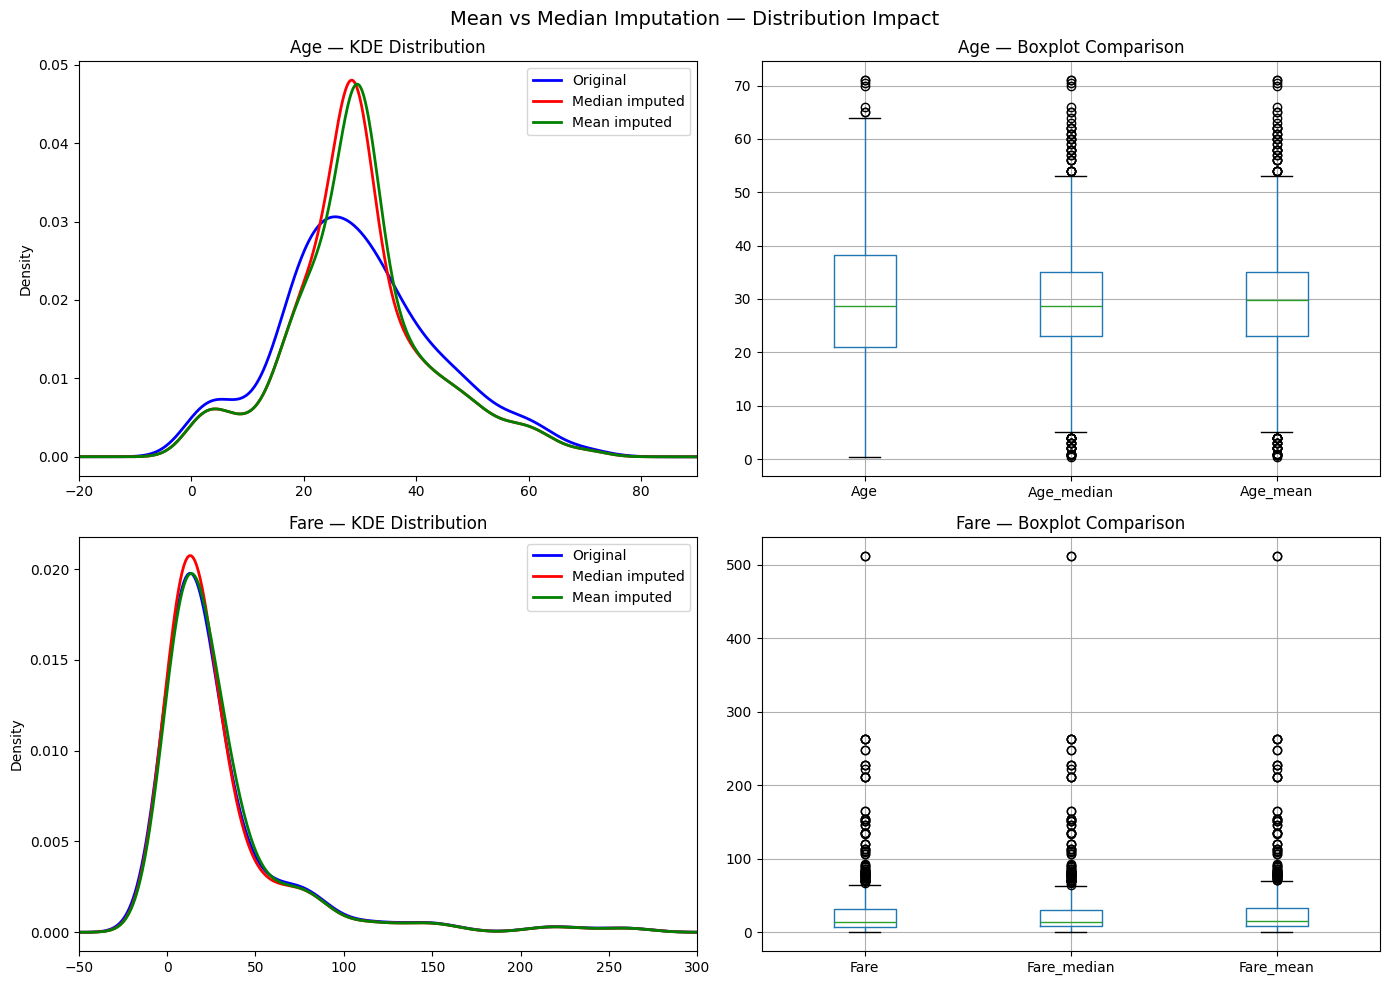

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mean vs Median Imputation — Distribution Impact", fontsize=14)

# Age KDE Plot
X_train['Age'].plot.kde(ax=axes[0][0], color='blue', label='Original', linewidth=2)
X_train['Age_median'].plot.kde(ax=axes[0][0], color='red',   label='Median imputed', linewidth=2)
X_train['Age_mean'].plot.kde(ax=axes[0][0], color='green', label='Mean imputed', linewidth=2)
axes[0][0].set_title("Age — KDE Distribution")
axes[0][0].legend()
axes[0][0].set_xlim(-20, 90)

# Age Boxplot Plot
X_train[['Age','Age_median','Age_mean']].boxplot(ax=axes[0][1])
axes[0][1].set_title("Age — Boxplot Comparison")

# Fare KDE Plot
X_train['Fare'].plot.kde(ax=axes[1][0], color='blue',  label='Original', linewidth=2)
X_train['Fare_median'].plot.kde( ax=axes[1][0], color='red',   label='Median imputed', linewidth=2)
X_train['Fare_mean'].plot.kde(ax=axes[1][0], color='green', label='Mean imputed', linewidth=2)
axes[1][0].set_title("Fare — KDE Distribution")
axes[1][0].legend()
axes[1][0].set_xlim(-50, 300)

# Fare Boxplot Plot
X_train[['Fare','Fare_median','Fare_mean']].boxplot(ax=axes[1][1])
axes[1][1].set_title("Fare — Boxplot Comparison")

plt.tight_layout()
plt.show()

### Correlation Impact Check

In [7]:
corr = X_train[['Age','Fare','Family',
                 'Age_median','Age_mean',
                 'Fare_median','Fare_mean']].corr()

print("Correlation matrix:")
print(corr.round(3))

print("\nKey correlation changes:")
print(f"Age vs Fare (original)        : {X_train['Age'].corr(X_train['Fare']):.4f}")
print(f"Age_median vs Fare (imputed)  : {X_train['Age_median'].corr(X_train['Fare']):.4f}")
print(f"Age_mean vs Fare (imputed)    : {X_train['Age_mean'].corr(X_train['Fare']):.4f}")

print(f"\nAge vs Family (original)      : {X_train['Age'].corr(X_train['Family']):.4f}")
print(f"Age_median vs Family (imputed): {X_train['Age_median'].corr(X_train['Family']):.4f}")

Correlation matrix:
               Age   Fare  Family  Age_median  Age_mean  Fare_median  \
Age          1.000  0.093  -0.299       1.000     1.000        0.087   
Fare         0.093  1.000   0.208       0.092     0.088        1.000   
Family      -0.299  0.208   1.000      -0.243    -0.245        0.206   
Age_median   1.000  0.092  -0.243       1.000     0.999        0.087   
Age_mean     1.000  0.088  -0.245       0.999     1.000        0.083   
Fare_median  0.087  1.000   0.206       0.087     0.083        1.000   
Fare_mean    0.090  1.000   0.205       0.090     0.086        0.997   

             Fare_mean  
Age              0.090  
Fare             1.000  
Family           0.205  
Age_median       0.090  
Age_mean         0.086  
Fare_median      0.997  
Fare_mean        1.000  

Key correlation changes:
Age vs Fare (original)        : 0.0926
Age_median vs Fare (imputed)  : 0.0918
Age_mean vs Fare (imputed)    : 0.0881

Age vs Family (original)      : -0.2991
Age_median vs Famil

In [8]:
def compare_imputation(df, col, mean_val, median_val):
    """
    Compares mean vs median imputation side by side
    for a given column
    """
    imputed_mean   = df[col].fillna(mean_val)
    imputed_median = df[col].fillna(median_val)

    print(f"COLUMN: {col}")
    print(f"Missing count  : {df[col].isnull().sum()}")
    print(f"Skewness       : {df[col].skew():.2f}")
    print(f"Recommendation : {'Median (skewed)' if abs(df[col].skew()) > 1 else 'Mean (symmetric)'}")
    print(f"\nMean value     : {mean_val:.2f}")
    print(f"Median value   : {median_val:.2f}")
    print(f"\nVariance original     : {df[col].var():.2f}")
    print(f"Variance after mean   : {imputed_mean.var():.2f}  ({((imputed_mean.var()/df[col].var())-1)*100:+.1f}%)")
    print(f"Variance after median : {imputed_median.var():.2f}  ({((imputed_median.var()/df[col].var())-1)*100:+.1f}%)")

compare_imputation(X_train, 'Age',  mean_age,  median_age)
compare_imputation(X_train, 'Fare', mean_fare, median_fare)

COLUMN: Age
Missing count  : 148
Skewness       : 0.33
Recommendation : Mean (symmetric)

Mean value     : 29.79
Median value   : 28.75

Variance original     : 204.35
Variance after mean   : 161.81  (-20.8%)
Variance after median : 161.99  (-20.7%)
COLUMN: Fare
Missing count  : 36
Skewness       : 4.55
Recommendation : Median (skewed)

Mean value     : 32.62
Median value   : 14.46

Variance original     : 2448.20
Variance after mean   : 2324.24  (-5.1%)
Variance after median : 2340.09  (-4.4%)
